## Trabajo Práctico
### Modelo de clasificación
#### Aprendizaje Automático I

**Carga de librerías**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Carga de datos**

In [33]:
data = pd.read_csv('weatherAUS.csv')

#### Análisis EDA

Muestra de datos generales.

In [34]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


Datos sobre las variables iniciales del dataset.

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Para agilizar la limpieza, se verifica si hay registros con solo valores nulos.

In [37]:
data.isna().all(axis=1).any()

False

No hay registros solo con datos nulos. Se verifica cuáles tienen nulos y qué porcentaje representa del total.

In [39]:
porc_nulos = data.isnull().sum()/len(data)*100

In [40]:
col_nulos = porc_nulos[porc_nulos>0].sort_values(ascending=False)

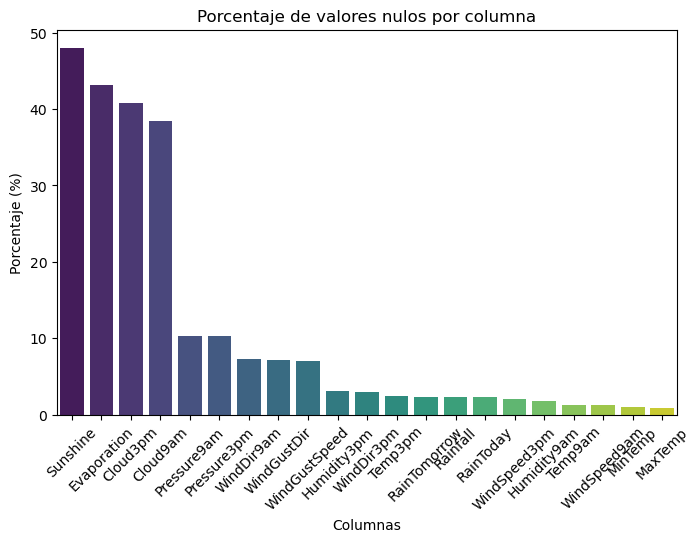

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Distribución de datos numéricos en histogramas.

In [49]:
data_num = data[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 
                 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am']]

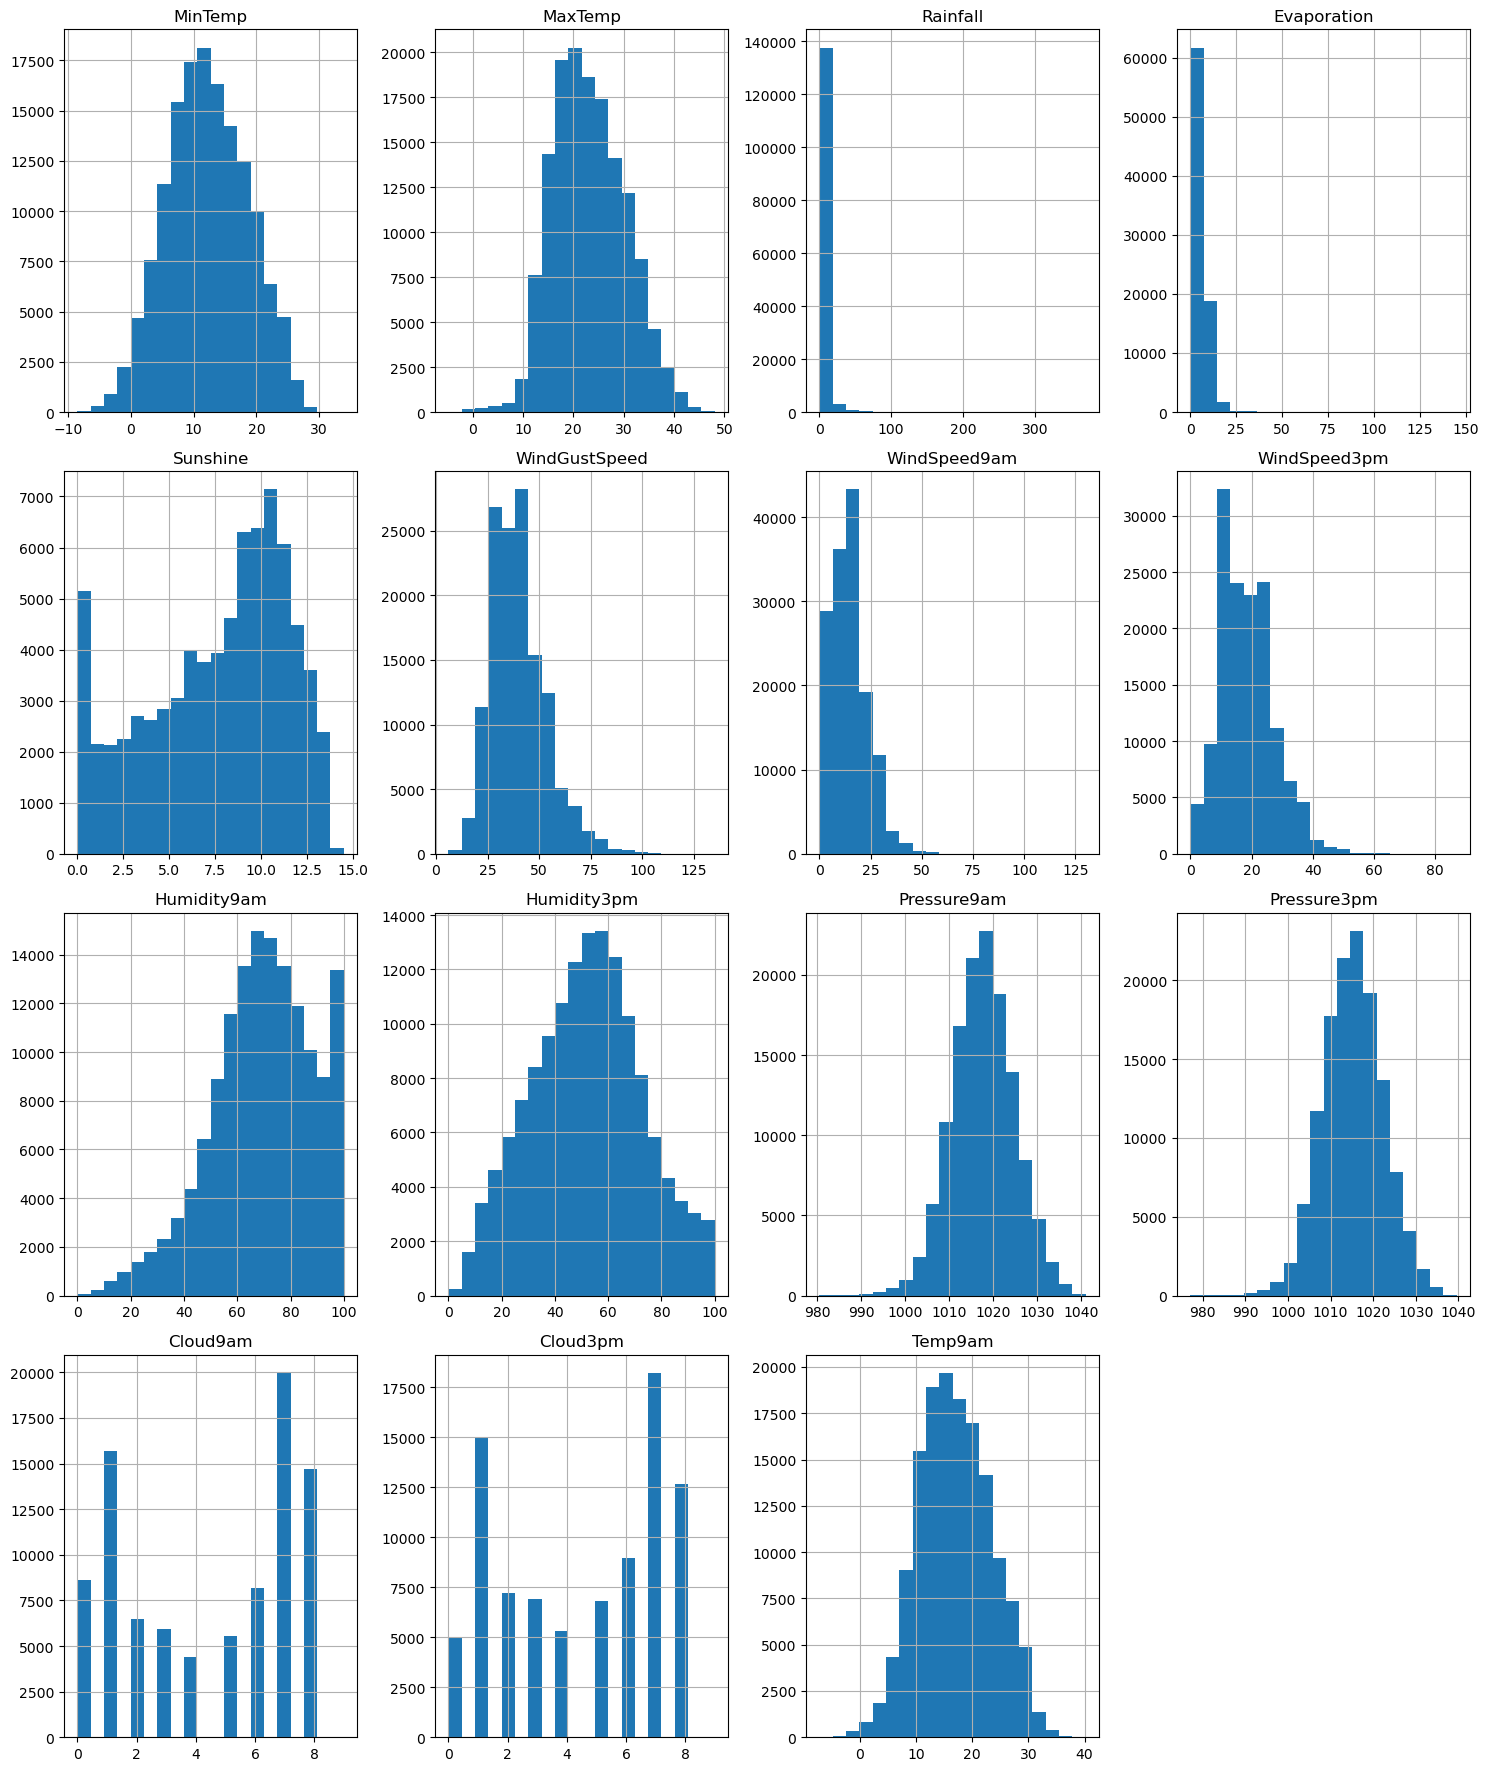

In [56]:
data_num.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

Detalles sobre las columnas categóricas.

In [58]:
data_cat = data[['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']]

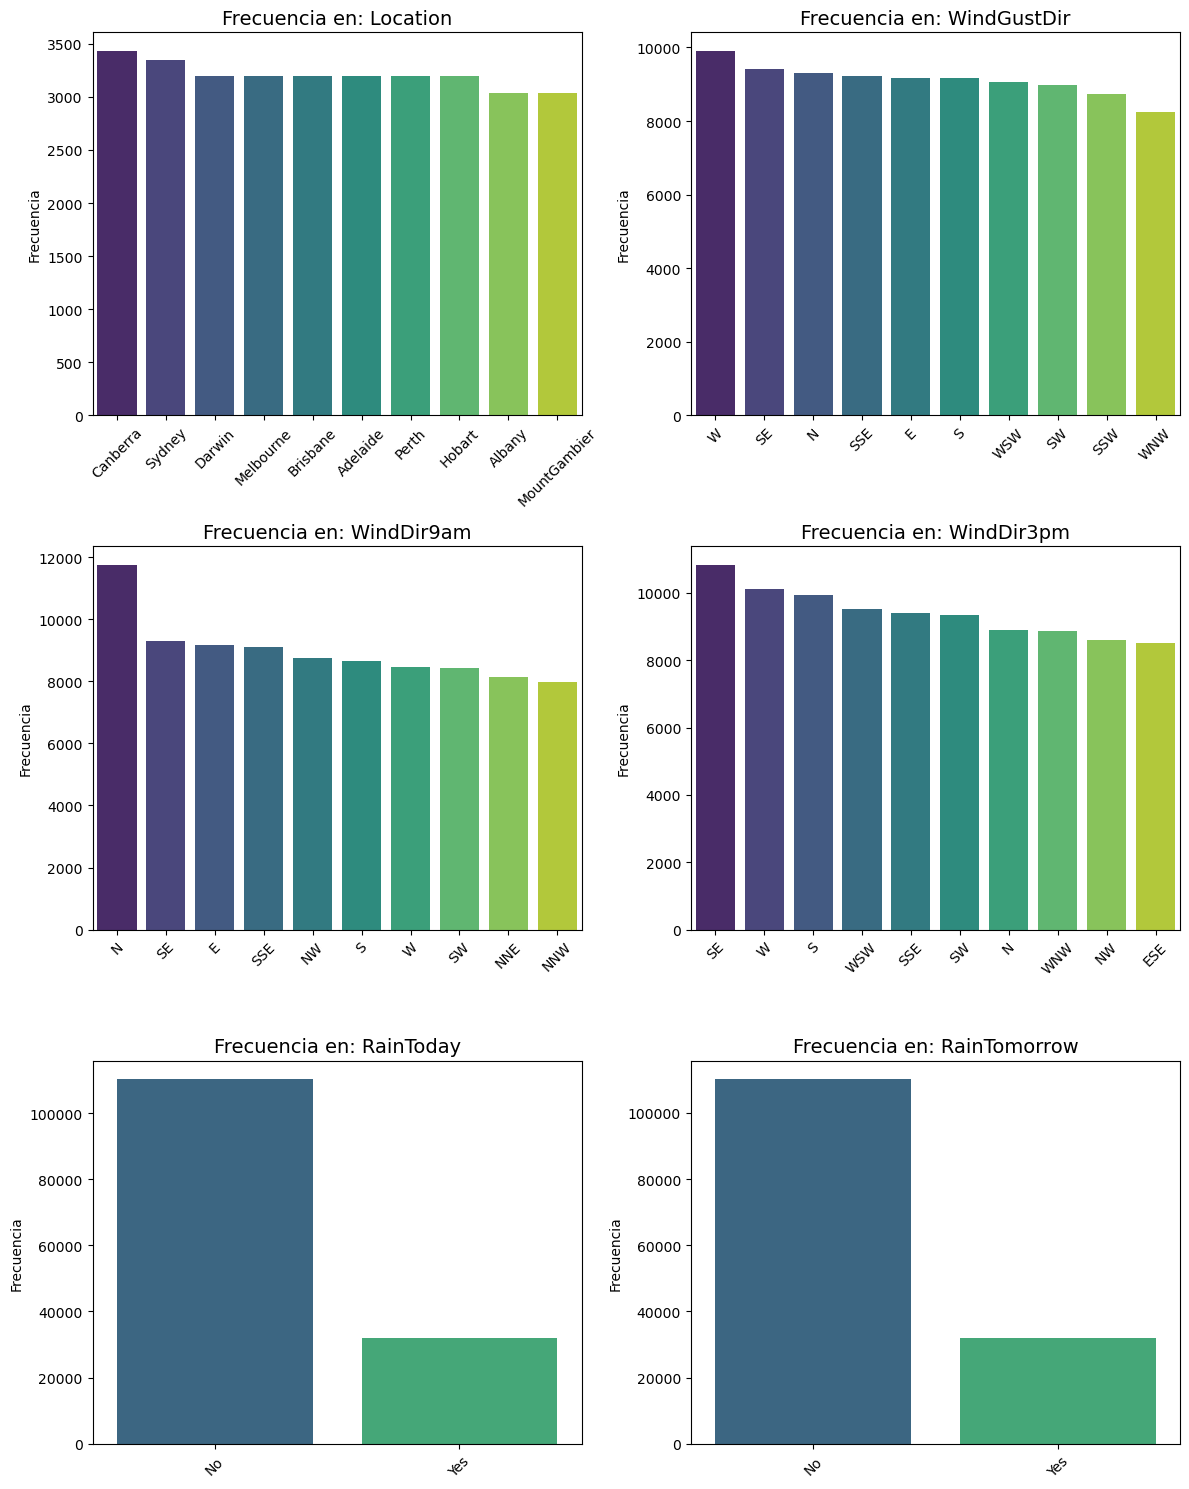

In [60]:
import math

n_cols = 2
n_rows = math.ceil(data_cat.shape[1] / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten()

# Se itera sobre cada columna categórica y crear su gráfico
for i, col in enumerate(data_cat.columns):
    top_cat = data_cat[col].value_counts().nlargest(10)
    
    sns.barplot(x=top_cat.index, y=top_cat.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Frecuencia en: {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Imputación de errores o datos faltantes

Al ser relevantes, se comienza visualizando más información sobre las ciudades del dataset.

In [8]:
data['Location'] = data['Location'].str.strip()

In [9]:
data['Location'].value_counts()

Location
Darwin              3062
Perth               3025
Brisbane            2953
MelbourneAirport    2929
PerthAirport        2913
SydneyAirport       2870
Watsonia            2730
Mildura             2594
MountGambier        2465
NorfolkIsland       2464
Cairns              2444
Townsville          2419
WaggaWagga          2416
AliceSprings        2223
Nuriootpa           2008
Hobart              1939
Moree               1913
Melbourne           1898
Portland            1863
Woomera             1734
Sydney              1690
Sale                1678
CoffsHarbour        1380
Williamtown         1198
Canberra            1078
Cobar                534
Name: count, dtype: int64

A fin de construir clusters en base a las ciudades observadas en el dataset, se buscan sus latitudes y longitudes para visualizarlas.

In [10]:
!pip install geonamescache

   ---------------------------------------- 0.0/32.0 MB ? eta -:--:--
    --------------------------------------- 0.5/32.0 MB 3.4 MB/s eta 0:00:10
   - -------------------------------------- 1.3/32.0 MB 3.5 MB/s eta 0:00:09
   -- ------------------------------------- 2.1/32.0 MB 3.5 MB/s eta 0:00:09
   --- ------------------------------------ 2.6/32.0 MB 3.4 MB/s eta 0:00:09
   ---- ----------------------------------- 3.4/32.0 MB 3.5 MB/s eta 0:00:09
   ----- ---------------------------------- 4.2/32.0 MB 3.5 MB/s eta 0:00:08
   ------ --------------------------------- 5.0/32.0 MB 3.5 MB/s eta 0:00:08
   ------- -------------------------------- 5.8/32.0 MB 3.6 MB/s eta 0:00:08
   -------- ------------------------------- 6.6/32.0 MB 3.6 MB/s eta 0:00:08
   -------- ------------------------------- 7.1/32.0 MB 3.5 MB/s eta 0:00:08
   --------- ------------------------------ 7.9/32.0 MB 3.5 MB/s eta 0:00:07
   ---------- ----------------------------- 8.4/32.0 MB 3.4 MB/s eta 0:00:07
   ---


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import geonamescache

In [12]:
gc = geonamescache.GeonamesCache()
ciudades = gc.get_cities()

In [13]:
ciudades_df = pd.DataFrame(ciudades).T

In [14]:
ciudades_df = ciudades_df[["name", "countrycode", "latitude", "longitude"]]
ciudades_df.rename(columns={"name": "Location"}, inplace=True)

In [15]:
data_completo = pd.merge(data, ciudades_df, on='Location', how='left')

Visualización de ciudades en mapa

In [16]:
import geopandas as gpd
import contextily as ctx

In [17]:
def crear_geodf(df, lon_col="longitude", lat_col="latitude"):
    """
    Convierte un DataFrame con columnas de latitud/longitud
    en un GeoDataFrame en proyección métrica (EPSG:3857)
    """
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"  # coordenadas geográficas
    )
    return gdf.to_crs(epsg=3857)

In [18]:
gdf = crear_geodf(data_completo)

In [19]:
def graf_mapa(geodf, titulo):
    fig, ax = plt.subplots(figsize=(10, 8))
    geodf.plot(ax=ax, color='red', markersize=60)

    # Mapa base
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    # Límites del mapa
    ax.set_xlim(geodf.total_bounds[0] - 1e6, geodf.total_bounds[2] + 1e6)
    ax.set_ylim(geodf.total_bounds[1] - 1e6, geodf.total_bounds[3] + 1e6)

    ax.set_title(titulo, fontsize=14)
    plt.show()

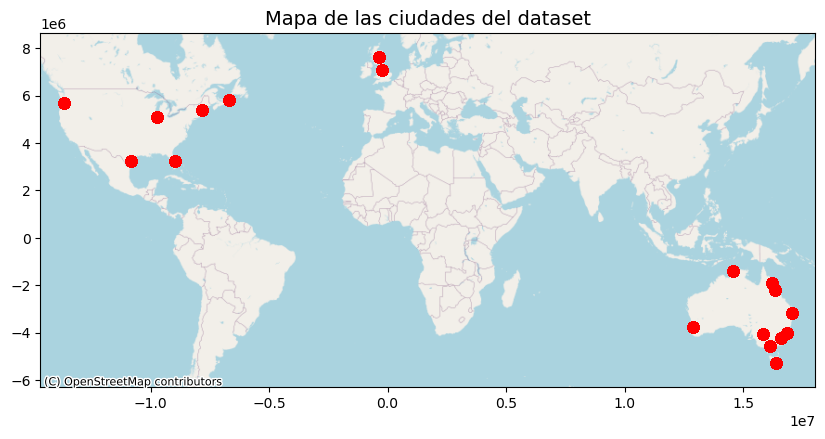

In [20]:
titulo = 'Mapa de las ciudades del dataset'
graf_mapa(gdf, titulo)

Como el presente análisis solo se centrará en Australia, se limitará a las ciudades situadas entre:
- Latitud: entre -44 y -10
- Longitud: entre 113 y 154.

In [21]:
def in_aus(lat, lon):
    return -44 <= lat <= -10 and 113 <= lon <= 154

# Filtro solo Australia
mask = data_completo.apply(lambda row: in_aus(row['latitude'], row['longitude']), axis=1)

data_aus = data_completo[mask].copy()

In [22]:
gdf = crear_geodf(data_aus)

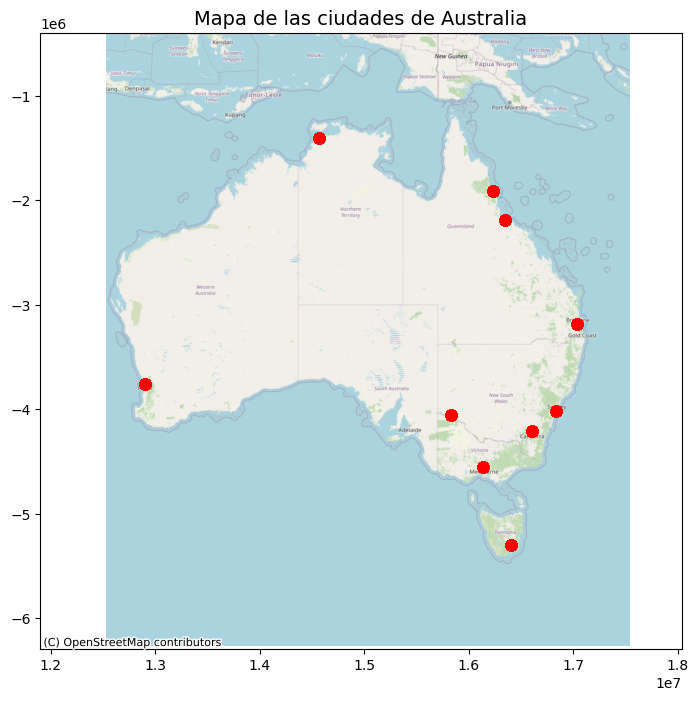

In [23]:
titulo = 'Mapa de las ciudades de Australia'
graf_mapa(gdf, titulo)

Ahora que solo quedaron los datos relacionados a Australia, se continúa con la clusterización de las regiones. Se hipotetiza que se propia dividir el mapa en cuatro regiones (norte, sur, este y oeste) pero se verificará con el método del codo.

In [24]:
from sklearn.cluster import KMeans

In [25]:
x = data_aus[['latitude', 'longitude']]

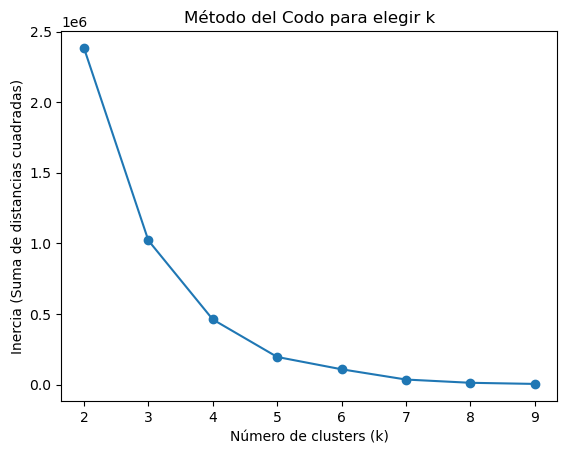

In [26]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias cuadradas)')
plt.title('Método del Codo para elegir k')
plt.show()

El método del codo demuestra que es mejor 5 que 4. Se graficará esta idea.

In [27]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
data_aus['region_cluster'] = kmeans.fit_predict(x)

Graficación de resultados de clusters

In [28]:
gdf = crear_geodf(data_aus)

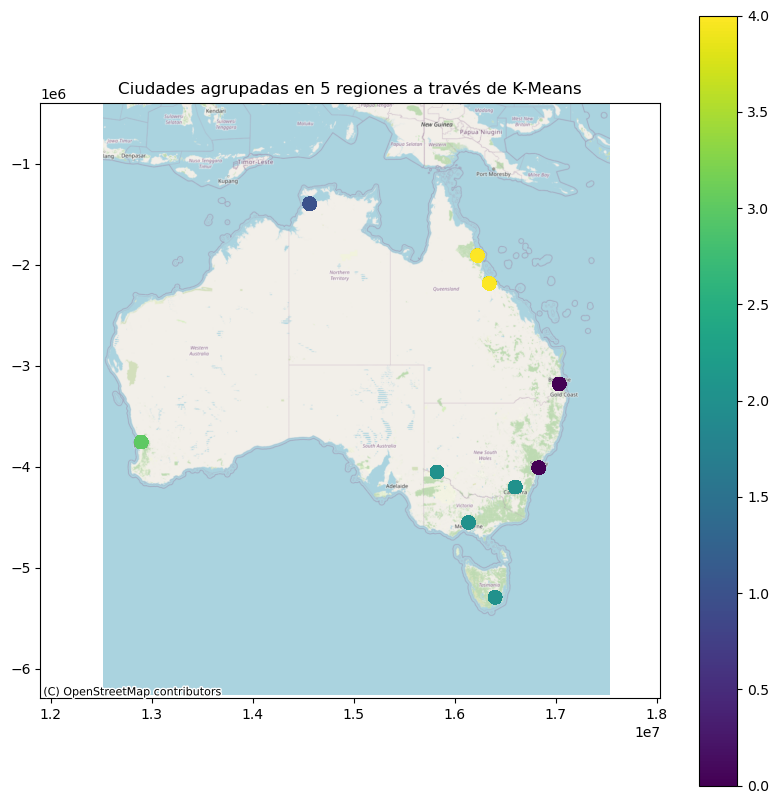

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column="region_cluster", legend=True, markersize=80, alpha=0.9)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_xlim(gdf.total_bounds[0] - 1e6, gdf.total_bounds[2] + 1e6)
ax.set_ylim(gdf.total_bounds[1] - 1e6, gdf.total_bounds[3] + 1e6)
ax.set_title(f"Ciudades agrupadas en {k} regiones a través de K-Means", fontsize=12)
plt.show()

In [30]:
data_aus['region_cluster'].value_counts()

region_cluster
2    7509
4    4863
0    4643
1    3062
3    3025
Name: count, dtype: int64